In [1]:
from metloom.pointdata import SnotelPointData
from datetime import datetime
import os
import glob
import pandas as pd
import xarray as xr
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

from scores.continuous import multiplicative_bias
from scores.continuous.correlation import pearsonr
from scores.continuous import kge

os.environ['PROJ_DATA'] = "C:/Users/RDCRLSMC/AppData/Local/miniconda3/envs/SIRO/Library/share/proj"
from model_comparison_functions import x_y_snotel

In [24]:
base_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/time_series/"

##All HMS uploads are Task 1
EB_t1 = glob.glob(os.path.join(base_dir, "HMS/Task1/EB/snow_depth_tif/", "*.tiff"))
EB_t2 = glob.glob(os.path.join(base_dir, "HMS/Task2/EB/snow_depth_tif/", "*.tiff"))

TI_t1 = glob.glob(os.path.join(base_dir, "HMS/Task1/TI/snow_depth_tif/", "*.tif"))
TI_t2 = glob.glob(os.path.join(base_dir, "HMS/Task2/TI/snow_depth_tif/", "*.tif"))

SM_t1 = glob.glob(os.path.join(base_dir, "SM/Task1/", "*.nc"))
SM_t2 = glob.glob(os.path.join(base_dir, "SM/Task2/", "*.nc"))

iSno_t1 = glob.glob(os.path.join(base_dir, "iSnobal/Task1", "*.tif"))
iSno_t2 = glob.glob(os.path.join(base_dir, "iSnobal/Task2/depth/", "*.tif"))


In [4]:
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID
snotel_point_BB = SnotelPointData("978:ID:SNTL", "Bogus Basin") # define the snotel ID

MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH])
    
BB_SNOTEL = snotel_point_BB.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_BB.ALLOWED_VARIABLES.SNOWDEPTH])  
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
BB_SNOTEL["SNOWDEPTH (m)"] = BB_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
MCS_SNOTEL = MCS_SNOTEL.reset_index()
BB_SNOTEL = BB_SNOTEL.reset_index()

MCS_SNOTEL["date"] = MCS_SNOTEL["datetime"].dt.date
BB_SNOTEL["date"] = BB_SNOTEL["datetime"].dt.date

In [5]:
MCS = x_y_snotel(snotel_point_MCS)
BB = x_y_snotel(snotel_point_BB)

In [35]:
def build_timeseries_netcdf(filelist, modelname, point):

    dfs = []

    for file in filelist:
        ds = xr.open_dataset(file, engine = 'netcdf4')

        # select nearest grid point
        ts = ds['SD'].sel(
            x=point[0],
            y=point[1],
            method="nearest"
        )

        # convert to dataframe WITH time preserved
        df = ts.to_dataframe(name=modelname).reset_index()

        # keep only relevant columns
        dfs.append(df[['time', modelname]])

    # combine all files into one time series
    out = pd.concat(dfs, ignore_index=True)

    # optional: sort by time
    out = out.sort_values('time').reset_index(drop=True)

    return out

In [36]:
def build_timeseries_tif(filelist, modelname, point):

    rasters = []

    for file in filelist:

        depth = rxr.open_rasterio(file).squeeze(drop=True)
        name, ext = os.path.splitext(os.path.basename(file))

        if 'TI' in name:
            parts = "-".join(name.split("_")[3:6])
            dt = datetime.strptime(parts, "%Y-%m-%dT%H%M")
        elif 'eb' in name:
            parts = "-".join(name.split("_")[7:10])
            dt = datetime.strptime(parts, "%Y-%m-%dT%H%M")
        elif 'mores_creek_depth' in name:
            parts = file.split("_")[-1][:10]
            dt = datetime.strptime(parts, "%Y-%m-%d")
        else:
            print("file not found")

        #dt = datetime.strptime(parts, "%Y-%m-%dT%H%M")

        depth = depth.expand_dims(datetime=[dt])
        rasters.append(depth)

    depth_ts = xr.concat(rasters, dim="datetime")
    ts = depth_ts.sel(
        x=point[0],
        y=point[1],
        method="nearest"
    )
    
    if 'HMS' in modelname:
        
        ts = ts * 0.0254
        
        
    df = ts.to_dataframe(name=modelname).reset_index()
    return df[["datetime", modelname]]

In [39]:
#Extract MCS SNOTEL values for task 1
EB_t1_MCS = build_timeseries_tif(EB_t1, "HMS_EB_t1", MCS)
TI_t1_MCS = build_timeseries_tif(TI_t1, "HMS_TI_t1", MCS)
SM_t1_MCS = build_timeseries_netcdf(SM_t1, "SnowModel_t1", MCS)
iSno_t1_MCS = build_timeseries_tif(iSno_t1,"iSnobal_t1", MCS)

#And Task 2
EB_t2_MCS = build_timeseries_tif(EB_t2, "HMS_EB_t2", MCS)
TI_t2_MCS = build_timeseries_tif(TI_t2, "HMS_TI_t2", MCS)
SM_t2_MCS = build_timeseries_netcdf(SM_t2, "SnowModel_t2", MCS)
iSno_t2_MCS = build_timeseries_tif(iSno_t2, "iSnobal_t2", MCS)

In [40]:
#Extract Bogus Basin SNOTEL values for task 1
EB_t1_bb = build_timeseries_tif(EB_t1, "HMS_EB_t1", BB)
TI_t1_bb = build_timeseries_tif(TI_t1, "HMS_TI_t1", BB)
SM_t1_bb = build_timeseries_netcdf(SM_t1, "SnowModel_t1", BB)
iSno_t1_bb = build_timeseries_tif(iSno_t1, "iSnobal_t1", BB)

#And Task 2
EB_t2_bb = build_timeseries_tif(EB_t2, "HMS_EB_t2", BB)
TI_t2_bb = build_timeseries_tif(TI_t2, "HMS_TI_t2", BB)
SM_t2_bb = build_timeseries_netcdf(SM_t2, "SnowModel_t2", BB)
iSno_t2_bb = build_timeseries_tif(iSno_t2, "iSnobal_t2", BB)

In [53]:
# 1. Align timezones/types and extract dates
df_MCS = pd.merge(pd.merge(pd.merge(EB_t1_MCS,TI_t1_MCS, on="datetime", how="outer"), EB_t2_MCS, on="datetime", how="outer"), TI_t2_MCS, on="datetime", how="outer")
df_MCS["datetime"] = pd.to_datetime(df_MCS["datetime"])
df_MCS["date"] = df_MCS["datetime"].dt.date
# Ensure time column is datetime in SnowModel
SM_merge = pd.merge(SM_t1_MCS, SM_t2_MCS, on="time", how="outer")
SM_merge["time"] = pd.to_datetime(SM_merge["time"])
SM_merge["date"] = SM_merge["time"].dt.date
# Ensure time column is datetime in iSnobal
iS_merge = pd.merge(iSno_t1_MCS, iSno_t2_MCS, on="datetime", how="outer")
iS_merge["datetime"] = pd.to_datetime(iS_merge["datetime"])
iS_merge["date"] = iS_merge["datetime"].dt.date

In [60]:
# 2. Merge datasets while PRESERVING 'datetime'
df_MCS = pd.merge(
    df_MCS[['datetime', 'HMS_EB_t1', 'HMS_TI_t1','HMS_EB_t2', 'HMS_TI_t2', 'date']],  # <-- Kept 'datetime' here
    MCS_SNOTEL[['date', 'SNOWDEPTH (m)']],
    on="date",
    how="left"
)

df_MCS = pd.merge(
    df_MCS,
    SM_merge[['date', 'SnowModel_t1', 'SnowModel_t2']],
    on="date",
    how="left"
)

df_MCS = pd.merge(
    df_MCS,
    iS_merge[['date', 'iSnobal_t1', 'iSnobal_t2']],
    on="date",
    how="left"
)

# 3. Clean and format the data
df_MCS = df_MCS.fillna(0)
df_MCS = df_MCS.round(2)

# 4. Set 'datetime' as the index before converting to Xarray Dataset
df_MCS = df_MCS.set_index("datetime")

# 5. Convert to Xarray Dataset
MCS_ds = xr.Dataset.from_dataframe(df_MCS)


In [63]:
# 1. Align timezones/types and extract dates
df_BB = pd.merge(pd.merge(pd.merge(EB_t1_bb,TI_t1_bb, on="datetime", how="outer"), EB_t2_bb, on="datetime", how="outer"), TI_t2_bb, on="datetime", how="outer")
df_BB["datetime"] = pd.to_datetime(df_BB["datetime"])
df_BB["date"] = df_BB["datetime"].dt.date
# Ensure time column is datetime in SnowModel
SM_merge = pd.merge(SM_t1_bb, SM_t2_bb, on="time", how="outer")
SM_merge["time"] = pd.to_datetime(SM_merge["time"])
SM_merge["date"] = SM_merge["time"].dt.date
# Ensure time column is datetime in iSnobal
iS_merge = pd.merge(iSno_t1_bb, iSno_t2_bb, on="datetime", how="outer")
iS_merge["datetime"] = pd.to_datetime(iS_merge["datetime"])
iS_merge["date"] = iS_merge["datetime"].dt.date

In [65]:
SM_merge

,time,SnowModel_t1,SnowModel_t2,date
0,2022-10-01 12:00:00,0.0,0.0,2022-10-01
1,2022-10-02 12:00:00,0.0,0.0,2022-10-02
2,2022-10-03 12:00:00,0.0,0.0,2022-10-03
3,2022-10-04 12:00:00,0.0,0.0,2022-10-04
4,2022-10-05 12:00:00,0.0,0.0,2022-10-05
...,...,...,...,...
802,2025-06-14 12:00:00,0.0,0.0,2025-06-14
803,2025-06-15 12:00:00,0.0,0.0,2025-06-15
804,2025-06-16 12:00:00,0.0,0.0,2025-06-16
805,2025-06-17 12:00:00,0.0,0.0,2025-06-17


In [66]:

df_BB = pd.merge(
    df_BB[['datetime','HMS_EB_t1', 'HMS_TI_t1','HMS_EB_t2', 'HMS_TI_t2', 'date']],
    BB_SNOTEL[['date', 'SNOWDEPTH (m)']],
    on="date",
    how="left"
)

df_BB = pd.merge(
    df_BB,
    SM_merge[['date', 'SnowModel_t1', 'SnowModel_t2']],
    on="date",
    how="left"
)

df_BB = pd.merge(
    df_BB,
    iS_merge[['date', 'iSnobal_t1', 'iSnobal_t2']],
    on="date",
    how="left"
)

df_BB = df_BB.fillna(0)
df_BB = df_BB.round(2)
df_BB = df_BB.set_index("datetime")

BB_ds = xr.Dataset.from_dataframe(df_BB)

In [189]:
years = BB_ds.datetime.dt.year

In [74]:
df_MCS

,HMS_EB_t1,HMS_TI_t1,HMS_EB_t2,HMS_TI_t2,date,SNOWDEPTH (m),SnowModel_t1,SnowModel_t2,iSnobal_t1,iSnobal_t2
datetime,,,,,,,,,,
2022-10-02,0.0,0.0,0.00,0.0,2022-10-02,0.0,0.0,0.0,0.0,0.0
2022-10-03,0.0,0.0,0.00,0.0,2022-10-03,0.0,0.0,0.0,0.0,0.0
2022-10-04,0.0,0.0,0.00,0.0,2022-10-04,0.0,0.0,0.0,0.0,0.0
2022-10-05,0.0,0.0,0.00,0.0,2022-10-05,0.0,0.0,0.0,0.0,0.0
2022-10-06,0.0,0.0,0.00,0.0,2022-10-06,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2025-05-26,0.0,0.0,0.23,0.0,2025-05-26,0.0,0.0,0.0,0.0,0.0
2025-05-27,0.0,0.0,0.18,0.0,2025-05-27,0.0,0.0,0.0,0.0,0.0
2025-05-28,0.0,0.0,0.13,0.0,2025-05-28,0.0,0.0,0.0,0.0,0.0


C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\siro_env\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


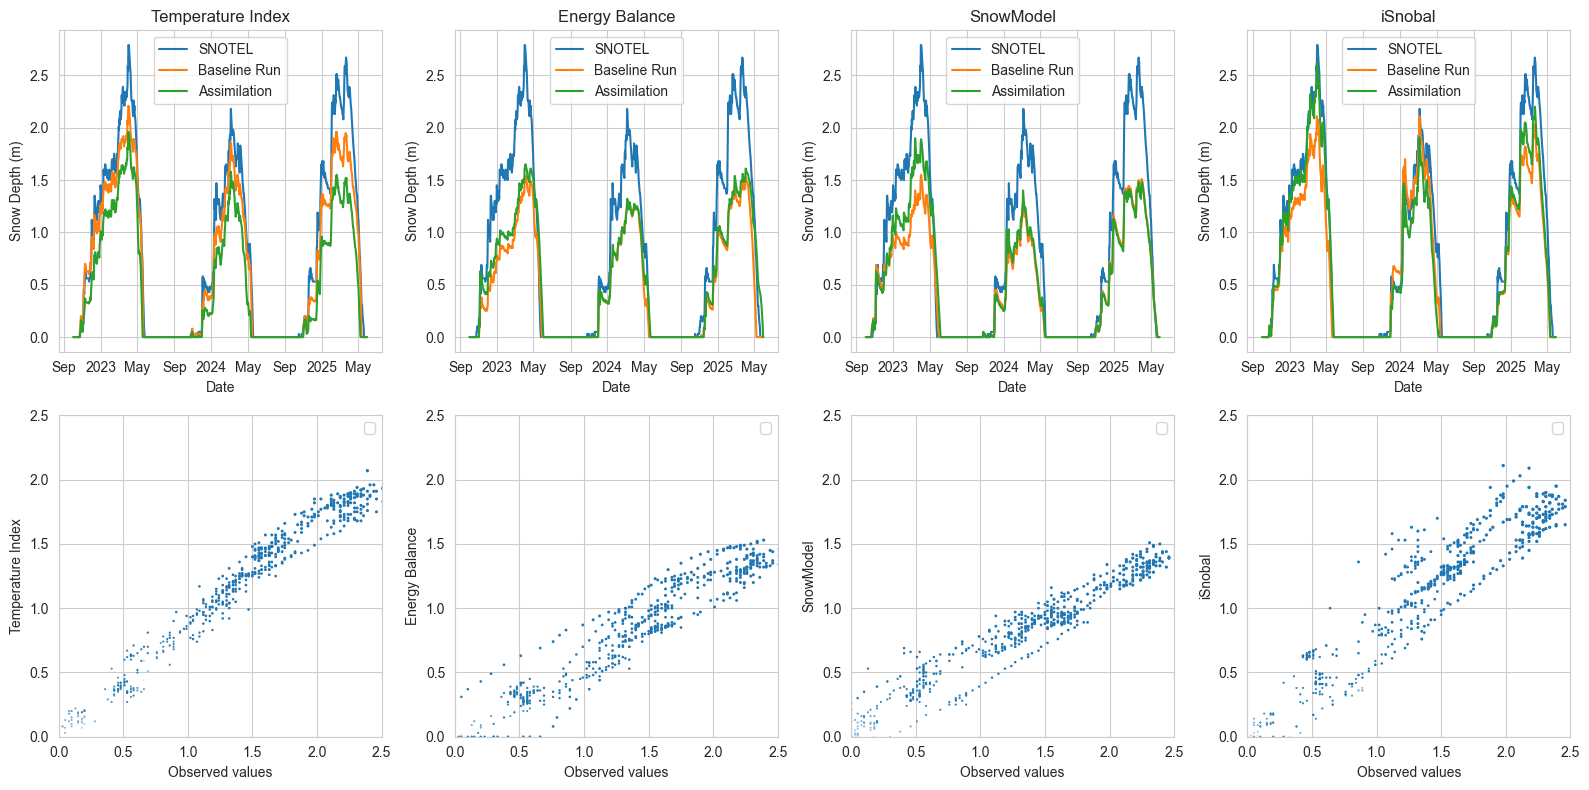

In [72]:
##Plots for MCS
obs = MCS_ds['SNOWDEPTH (m)']
fcst1_a = MCS_ds['HMS_TI_t1']
fcst1_b = MCS_ds['HMS_TI_t2']

fcst2_a = MCS_ds['HMS_EB_t1']
fcst2_b = MCS_ds['HMS_EB_t2']

fcst3_a = MCS_ds['SnowModel_t1']
fcst3_b = MCS_ds['SnowModel_t2']

fcst4_a = MCS_ds['iSnobal_t1']
fcst4_b = MCS_ds['iSnobal_t2']

forecasts = [
    ("Temperature Index", fcst1_a, fcst1_b),
    ("Energy Balance", fcst2_a, fcst2_b),
    ("SnowModel", fcst3_a, fcst3_b),
    ("iSnobal", fcst4_a, fcst4_b),
]

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst_a, fcst_b) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="SNOTEL")
    fcst_a.plot(ax=axs[0, i], label="Baseline Run")
    fcst_b.plot(ax=axs[0, i], label="Assimilation")

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].set_xlabel("Date")
    axs[0, i].legend()
    axs[0, i].set_title(name)

    # Scatter plot
    scatter = axs[1, i].scatter(obs.values, fcst_a.values,fcst_b.values,
                                #c = years
                                )
    handles, labels = scatter.legend_elements()
    #wy_labels = [f"WY {int(y)}" for y in np.unique(years)]

    axs[1, i].set_xlabel("Observed values")
    axs[1, i].set_ylabel(f"{name}")
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)
    axs[1,i].legend(handles=handles, 
                    #labels=wy_labels,
                    #title="Water Year"
                    )

    # obs_vals = obs.values.flatten()
    # fcst_a_vals = fcst_a.values.flatten()
    # fcst_b_vals = fcst_b.values.flatten()
    #
    # bias = multiplicative_bias(fcst, obs).item()
    # corr = pearsonr(fcst, obs).item()
    #
    # axs[0, i].set_title(
    #     f"{name}\n"
    #     f"Multiplicative bias = {bias:.3f}, "
    #     f"Correlation = {corr:.2f}"
    # )

plt.tight_layout()
# plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_MCS.png', dpi = 300)
plt.show()

In [155]:
for i, (name, fcst) in enumerate(forecasts):
    # Call the 'kge' function, store result in 'kge_score'
    kge_score = kge(fcst, obs, include_components=True)
    print(f"{name}: KGE = {kge_score['kge'].item():.3}, correlation(rho) = {kge_score['rho'].item():.3}, variability(alpha) = {kge_score['alpha'].item():.3}, bias(beta) = {kge_score['beta'].item():.3}")


HMS_TI: KGE = 0.509, correlation(rho) = 0.981, variability(alpha) = 0.68, bias(beta) = 0.628
HMS_EB: KGE = 0.525, correlation(rho) = 0.971, variability(alpha) = 0.65, bias(beta) = 0.68
SnowModel: KGE = 0.434, correlation(rho) = 0.985, variability(alpha) = 0.588, bias(beta) = 0.612
iSnobal: KGE = 0.726, correlation(rho) = 0.977, variability(alpha) = 0.81, bias(beta) = 0.803


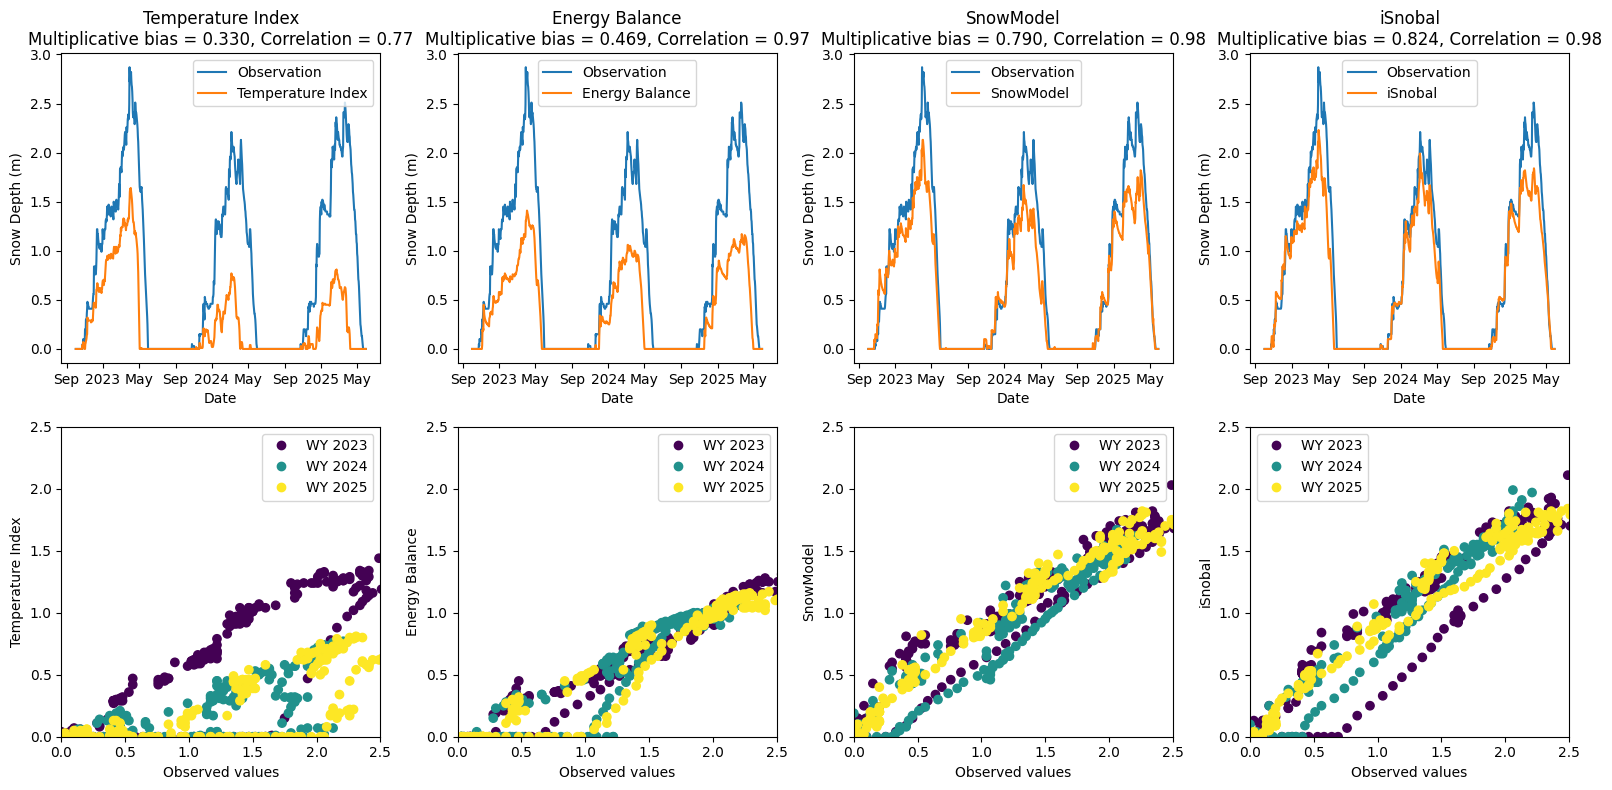

In [222]:
##Plots for BB
obs = BB_ds['SNOWDEPTH (m)']
fcst1 = BB_ds['HMS_TI']
fcst2 = BB_ds['HMS_EB']
fcst3 = BB_ds['SnowModel']
fcst4 = BB_ds['iSnobal']

forecasts = [
    ("Temperature Index", fcst1),
    ("Energy Balance", fcst2),
    ("SnowModel", fcst3),
    ("iSnobal", fcst4)
]

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i, (name, fcst) in enumerate(forecasts):

    obs.plot(ax=axs[0, i], label="Observation")
    fcst.plot(ax=axs[0, i], label=name)

    axs[0, i].set_ylabel("Snow Depth (m)")
    axs[0, i].set_xlabel("Date")
    axs[0, i].legend()

    months = fcst.datetime.dt.month
    years = xr.where(
        months > 9,
        fcst.datetime.dt.year + 1,
        fcst.datetime.dt.year
    )
    # Scatter plot
    scatter = axs[1, i].scatter(obs.values, fcst.values, c = years)
    handles, labels = scatter.legend_elements()
    wy_labels = [f"WY {int(y)}" for y in np.unique(years)]

    axs[1, i].set_xlabel("Observed values")
    axs[1, i].set_ylabel(f"{name}")
    axs[1, i].set_xlim(0, 2.5)
    axs[1, i].set_ylim(0, 2.5)
    axs[1,i].legend(handles=handles, 
                    labels=wy_labels, 
                    #title="Water Year"
                    )

    obs_vals = obs.values.flatten()
    fcst_vals = fcst.values.flatten()
    
    bias = multiplicative_bias(fcst, obs).item()
    corr = pearsonr(fcst, obs).item()

    axs[0, i].set_title(
        f"{name}\n"
        f"Multiplicative bias = {bias:.3f}, "
        f"Correlation = {corr:.2f}"
    )

plt.tight_layout()
plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/KGE_BB.png', dpi = 300)
plt.show()